# Time Series Analysis: Indexing

In [15]:
# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## DSTree

The DSTree is arguably the most complex data structure in this course. It tries to tackle several problems of other indexing methods:
1. 
2.
3.



### Implementation

In [16]:
class DSNode:
    def __init__(self, max_items_per_node, ts_list=None, segmentation=None, synopsis=None):
        self.left = None
        self.right = None

        self.max_items_per_node = max_items_per_node
        self.file = ts_list

        self.segmentation = segmentation
        self.synopsis = synopsis

        self.splitting_strategy = None
        self.split_threshold = None


    @property
    def children(self):
        return (self.left, self.right)
    
    @property
    def count(self):
        return len(self.file)

    def is_leaf(self):
        return self.left == None and self.right == None
    
    def is_full(self):
        return len(self.file) >= self.max_items_per_node
    
    def add_to_file(self, ts):
        self.file.append(ts)

    def update_synopsis(self, ts):
        # go through each segment and calculate new measures
        for i, (l_seg, r_seg) in enumerate(self.segmentation):
            segment = ts[l_seg:r_seg]
            s_mean = np.mean(segment)
            s_std = np.std(segment)

            self.synopsis[i]["mean_min"] = np.min([self.synopsis[i]["mean_min"], s_mean])
            self.synopsis[i]["mean_max"] = np.max([self.synopsis[i]["mean_max"], s_mean])
            self.synopsis[i]["std_min"] = np.min([self.synopsis[i]["std_min"], s_std])
            self.synopsis[i]["std_max"] = np.max([self.synopsis[i]["std_max"], s_std])

    def route_to_child(self, query):
        idx_seg, strategy, measure = self.splitting_strategy
        l_seg, r_seg = self.segmentation[idx_seg]

        if strategy == "H_Split":
            start, end = l_seg, r_seg
        else:
            mid_seg = (l_seg + r_seg) // 2
            start, end = (l_seg, mid_seg) if strategy == "V_Split_Left" else (mid_seg, r_seg)

        # Calculate the query's measure for the target segment
        val = np.mean(query[start:end]) if measure == "mean" else np.std(query[start:end])

        # Route using the cached threshold
        if val < self.split_threshold:
            return self.left
        else:
            return self.right

    def create_children(self):
        idx_seg, strategy, measure = self.splitting_strategy
        l_seg, r_seg = self.segmentation[idx_seg]
        
        # 1: Prepare segmentation and bounds
        if strategy == "H_Split":
            new_segmentation = self.segmentation.copy()
            start, end = l_seg, r_seg
        else:
            mid_seg = (l_seg + r_seg) // 2
            new_segmentation = self.segmentation[:idx_seg] + [(l_seg, mid_seg), (mid_seg, r_seg)] + self.segmentation[idx_seg+1:]
            start, end = (l_seg, mid_seg) if strategy == "V_Split_Left" else (mid_seg, r_seg)

        # 2: Vectorized split using the cached threshold
        ts_matrix = np.array(self.file)
        target_data = ts_matrix[:, start:end]
        m_vals = np.mean(target_data, axis=1) if measure == "mean" else np.std(target_data, axis=1)
        
        left_mask = m_vals < self.split_threshold
        left_ts_matrix = ts_matrix[left_mask]
        right_ts_matrix = ts_matrix[~left_mask]

        # 3: Vectorized Synopsis creation
        left_synopsis, right_synopsis = [], []
        for l, r in new_segmentation:
            left_synopsis.append({
                "mean_min": np.min(np.mean(left_ts_matrix[:, l:r], axis=1)),
                "mean_max": np.max(np.mean(left_ts_matrix[:, l:r], axis=1)),
                "std_min": np.min(np.std(left_ts_matrix[:, l:r], axis=1)),
                "std_max": np.max(np.std(left_ts_matrix[:, l:r], axis=1)),
            })
            right_synopsis.append({
                "mean_min": np.min(np.mean(right_ts_matrix[:, l:r], axis=1)),
                "mean_max": np.max(np.mean(right_ts_matrix[:, l:r], axis=1)),
                "std_min": np.min(np.std(right_ts_matrix[:, l:r], axis=1)),
                "std_max": np.max(np.std(right_ts_matrix[:, l:r], axis=1)),
            })

        # 4: Create children
        self.left = DSNode(self.max_items_per_node, left_ts_matrix.tolist(), new_segmentation, left_synopsis)
        self.right = DSNode(self.max_items_per_node, right_ts_matrix.tolist(), new_segmentation, right_synopsis)

        # 5: Free memory
        self.file = None

    def _calculate_qos(self, ts_matrix, segmentation):
        # Handle empty node
        if len(ts_matrix) == 0:
            return 0
        
        estimation_quality = 0
        for l_seg, r_seg in segmentation:
            seg_data = ts_matrix[:, l_seg:r_seg]
            
            # Extract components for QoS: max_mean, min_mean, max_std
            mean_vals = np.mean(seg_data, axis=1)
            std_vals = np.std(seg_data, axis=1)
            
            # Estimation quality formula
            term = (np.max(mean_vals) - np.min(mean_vals))**2 + np.max(std_vals)**2
            estimation_quality += (r_seg - l_seg) * term
            
        return estimation_quality

    def find_best_split(self):
        # 1: Preparation
        ts_matrix = np.array(self.file)
        strategies = ["H_Split", "V_Split_Left", "V_Split_Right"]
        measures = ["mean", "std"]
        
        best_benefit = np.inf

        # 2: Evaluate all possible splitting strategies across all segments
        for idx_seg, (l_seg, r_seg) in enumerate(self.segmentation):
            for strategy in strategies:
                for measure in measures:
                    
                    # 2.1: Determine the refined segmentation and target slicing bounds
                    if strategy == "H_Split":
                        new_segmentation = self.segmentation.copy()
                        start, end = l_seg, r_seg
                    else:
                        mid_seg = (l_seg + r_seg) // 2
                        new_segmentation = self.segmentation[:idx_seg] + [(l_seg, mid_seg), (mid_seg, r_seg)] + self.segmentation[idx_seg+1:]
                        start, end = (l_seg, mid_seg) if strategy == "V_Split_Left" else (mid_seg, r_seg)
                    
                    # 2.2: Compute the target measure to find the split threshold
                    target_data = ts_matrix[:, start:end]
                    if measure == "mean":
                        m_vals = np.mean(target_data, axis=1)
                    else:
                        m_vals = np.std(target_data, axis=1)
                        
                    threshold = (np.min(m_vals) + np.max(m_vals)) / 2
                    
                    # 2.3: Simulate the split using boolean indexing (much faster than list comprehensions)
                    left_mask = m_vals < threshold
                    right_mask = ~left_mask
                    
                    left_ts_matrix = ts_matrix[left_mask]
                    right_ts_matrix = ts_matrix[right_mask]

                    # Skip dead-end splits that don't actually divide the data
                    if len(left_ts_matrix) == 0 or len(right_ts_matrix) == 0:
                        continue
                    
                    # 2.4: Compute QoS for the simulated children
                    qos_left = self._calculate_qos(left_ts_matrix, new_segmentation)
                    qos_right = self._calculate_qos(right_ts_matrix, new_segmentation)
                    benefit = qos_left + qos_right
                    
                    # 2.5: Track the best strategy
                    if benefit < best_benefit:
                        best_benefit = benefit
                        self.splitting_strategy = (idx_seg, strategy, measure)
                        self.split_threshold = threshold

    def calc_min_dist(self, query):        
        best_dist = np.inf
        best_ts = None

        for ts in self.file:
            # Using euclidean distance
            dist = np.sqrt(np.sum((ts - query)  ** 2))

            if dist < best_dist:
                best_dist = dist
                best_ts = ts

        return best_ts, best_dist
    
    def lower_bound(self, query):
        lower_bound_sq = 0.0
        
        for i, (l_seg, r_seg) in enumerate(self.segmentation):
            syn = self.synopsis[i]
            segment = query[l_seg:r_seg]
            
            # 1: Calculate query segment statistics
            q_mean = np.mean(segment)
            q_std = np.std(segment)

            # 2: Calculate squared distance to the synopsis bounding box
            lb_mean = (q_mean - np.clip(q_mean, syn["mean_min"], syn["mean_max"])) ** 2
            lb_std  = (q_std  - np.clip(q_std,  syn["std_min"],  syn["std_max"]))  ** 2
            
            # 3: Accumulate the weighted segment penalty
            lower_bound_sq += (r_seg - l_seg) * (lb_mean + lb_std)

        return np.sqrt(lower_bound_sq)
    
    def upper_bound(self, query):
        upper_bound_sq = 0.0

        for i, (l_seg, r_seg) in enumerate(self.segmentation):
            syn = self.synopsis[i]
            segment = query[l_seg:r_seg]

            q_mean = np.mean(segment)
            q_std = np.std(segment)
            
            # 2: Upper bound for mean (max distance to endpoints)
            dist_to_min = abs(q_mean - syn["mean_min"])
            dist_to_max = abs(q_mean - syn["mean_max"])
            ub_mean = max(dist_to_min, dist_to_max) ** 2

            ub_std = (syn["std_max"] + q_std) ** 2

            upper_bound_sq += (r_seg - l_seg) * (ub_mean + ub_std)

        return np.sqrt(upper_bound_sq)

In [ ]:
import heapq

class DSTree:
    def __init__(self, max_items_per_node, time_series=None):
        self.max_items_per_node = max_items_per_node

        if time_series == None:
            self.root = None
        else:
            self.insert(time_series)

    def insert(self, ts):
        if self.root == None:
            # Fit root input to note structure
            self.root = DSNode(
                            max_items_per_node=self.max_items_per_node,
                            ts_list=[ts],
                            segmentation=[(0, len(ts))],
                            synopsis=[{
                                "mean_min": np.mean(ts), 
                                "mean_max": np.mean(ts), 
                                "std_min": np.std(ts), 
                                "std_max": np.std(ts)
                            }]
            )
        
        self._insert(self.root, ts)
        
    def _insert(self, node, ts):
        # 1: Update upper and lower bounds of current node to given time series
        node.update_synopsis(ts)

        # 2: Check whether current node is a leaf
        if node.is_leaf():
            # 2.1.1: If leaf reached add time series
            node.add_to_file(ts)

            # 2.1.2: If leaf is full now, split into two children
            if node.is_full():
                node.find_best_split()
                node.create_children()
        else:
            # 2.2: If not leaf yet traverse down the tree
            child = node.route_to_child(ts)
            self._insert(child, ts)

    def heuristic_search(self, query):
        # Traverse down to a leaf given query statistics
        node = self.root
        while not node.is_leaf():
            node = node.route_to_child(query)

        return node

    def exact_search(self, query):
        # 1: Perform heuristic seach of similar time series
        best_node = self.heuristic_search(query)
        best_ts, best_dist = best_node.calc_min_dist(query)
        
        # 2: Add root as entry point to priority queue of nodes possibly containing similarity match
        node_candidates = [(self.root.lower_bound(query), 0, self.root)]
        counter = 0

        # 3: Loop through nodes until all are evaluated
        while node_candidates:
            current_lb, _, current_node = heapq.heappop(node_candidates)

            # Early stop: Best candidate has too high lower bound
            if current_lb > best_dist:
                break
            
            # 3.1: Compare the best so far to best match in candidate node
            if current_node.is_leaf():
                ts, dist = current_node.calc_min_dist(query)

                if dist < best_dist:
                    best_dist = dist
                    best_ts = ts

            # 3.2: Traverse down the inner nodes
            else:
                for child_node in current_node.children:
                    child_lb = child_node.lower_bound(query)
                    
                    if child_lb < best_dist:
                        counter += 1
                        heapq.heappush(node_candidates, (child_lb, counter, child_node))
        
        return best_ts, best_dist

    def histogram(self, query, num_bins=20):
        # 1: Track statistics of leafs and nodes to be processed
        range_counts = []
        node_bounds_stack = [(self.root, -np.inf, np.inf)]

        # 2: Traverse the tree (alpha-traversal could be implemented)
        while node_bounds_stack:
            # 2.1: Enforce passing down of tight bounds
            current_node, parent_lb, parent_ub = node_bounds_stack.pop()
            
            current_lb = current_node.lower_bound(query)
            current_ub = current_node.upper_bound(query)

            tight_lb = max(parent_lb, current_lb)
            tight_ub = min(parent_ub, current_ub)

            # 2.2: Collect leaf statistics or prepare further traversal
            if current_node.is_leaf():
                count = current_node.count
                range_counts.append((tight_lb, tight_ub, count))
            else:
                for child_node in current_node.children:
                    node_bounds_stack.append((child_node, tight_lb, tight_ub))
        
        # 3: Transform gathered leaf statistics to histogram
        return self._build_histogram(range_counts, num_bins)
        
    def _build_histogram(self, range_counts, num_bins):
        # Initializing histogram structure
        min_dist = min(lb for lb, _, _ in range_counts)
        max_dist = max(ub for _, ub, _ in range_counts)
        bins = np.linspace(min_dist, max_dist, num_bins + 1)
        hist = np.zeros(num_bins)

        for lb, ub, count in range_counts:
            # Zero-width range handling
            if ub == lb:
                bin_idx = np.clip(np.digitize(lb, bins) - 1, 0, num_bins - 1)
                hist[bin_idx] += count
                continue
            
            # Assume uniform distribution
            density = count / (ub - lb)
            
            # Identify and overlay intersections between node range and current slots
            for i in range(num_bins):
                overlap = max(0, min(ub, bins[i+1]) - max(lb, bins[i]))
                hist[i] += density * overlap

        return hist, bins 


### Experiments

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Global Control Parameters
# ==========================================
n_ts = 100           # Number of individual time series to generate
ts_length = 100    # Number of data points per time series
noise_level = 1   # Standard deviation of the white noise

# Set seed for reproducibility (optional)
np.random.seed(42)

# ==========================================
# 2. Setup Dimensions for Broadcasting
# ==========================================
# Time vector reshaped to (ts_length, 1) to act as the vertical axis
t = np.linspace(0, 20, ts_length).reshape(-1, 1)

# ==========================================
# 3. Individual Random Characteristics
# ==========================================
# We generate arrays of shape (1, n_ts) so each series gets its own unique parameter

# Random frequencies for the sine and cosine waves (e.g., between 0.1 and 1.5 Hz)
freq_sin = np.random.uniform(0.1, 1.5, size=(1, n_ts))
freq_cos = np.random.uniform(0.1, 1.5, size=(1, n_ts))

# Random amplitudes (how tall the waves are)
amp_sin = np.random.uniform(2.0, 10.0, size=(1, n_ts))
amp_cos = np.random.uniform(2.0, 10.0, size=(1, n_ts))

# Random phase shifts (sliding the wave left or right)
phase_sin = np.random.uniform(0, 2 * np.pi, size=(1, n_ts))
phase_cos = np.random.uniform(0, 2 * np.pi, size=(1, n_ts))

# Random linear trends (drifting up or down over time)
trends = np.random.uniform(-3.0, 3.0, size=(1, n_ts))

# Random starting offsets (y-intercept)
intercepts = np.random.uniform(-20, 20, size=(1, n_ts))

# ==========================================
# 4. Construct the Time Series Set
# ==========================================
# Base Signals
wave_sin = amp_sin * np.sin(2 * np.pi * freq_sin * t + phase_sin)
wave_cos = amp_cos * np.cos(2 * np.pi * freq_cos * t + phase_cos)
linear_drift = (trends * t) + intercepts

# Noise Matrix of shape (ts_length, n_ts)
noise = np.random.normal(loc=0, scale=noise_level, size=(ts_length, n_ts))

# Combine all matrices! 
# ts_matrix is now a perfect (1000, 50) numpy array
ts_matrix = wave_sin + wave_cos + linear_drift + noise

# # ==========================================
# # 5. Visualization
# # ==========================================
# plt.figure(figsize=(14, 6))

# # Plot a subset (first 5 series) so the chart isn't an unreadable mess
# plt.plot(t, ts_matrix[:, :], alpha=0.85, linewidth=1.5)

# plt.title(f"Synthetic Dataset: 5 Random Samples (out of {n_ts} generated)", fontsize=14)
# plt.xlabel("Time", fontsize=12)
# plt.ylabel("Amplitude", fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.show()

In [19]:
ts_matrix.shape

(100, 100)

In [24]:
ds_tree = DSTree(max_items_per_node=100)

for ts in ts_matrix[1:, :]:
    ds_tree.insert(ts)

In [25]:
def serial_search(query, target):
    best_dist = np.inf
    best_ts = []

    for ts in target:
        dist = np.sqrt(np.sum((query - ts) ** 2))
        if dist < best_dist:
            best_dist = dist
            best_ts = ts

    return best_ts, best_dist

In [26]:
%%time
best_ts_dstree, best_dist_dstree = ds_tree.exact_search(ts_matrix[0, :])

CPU times: user 2.67 ms, sys: 0 ns, total: 2.67 ms
Wall time: 2.68 ms


In [27]:
%%time
best_ts_serial, best_dist_serial = serial_search(ts_matrix[0, :], ts_matrix[1:, :])

CPU times: user 971 μs, sys: 0 ns, total: 971 μs
Wall time: 977 μs


In [28]:
np.all(best_ts_dstree == best_ts_serial)

np.True_

In [31]:
ds_tree.exact_search(ts_matrix[0, :])

([7.942044548775277,
  -17.94783721282626,
  -17.065060436050054,
  -6.427139198424512,
  -5.620226400595932,
  18.644333084700552,
  -0.31714178538331755,
  24.087153111066918,
  -1.033349973645159,
  10.217026478504522,
  14.140677917271704,
  8.126439024784407,
  6.839776031179262,
  -1.5723815412771667,
  -11.637411084375572,
  15.640926751454183,
  11.91533915102196,
  21.968670625856067,
  -19.801167071103762,
  1.8241487504121756,
  18.13638004846307,
  -24.05246674069866,
  -9.161166479065914,
  9.633680497591097,
  16.14289133010685,
  2.8729232406719185,
  -18.61199913416104,
  6.339782003703762,
  -10.588423386066768,
  -5.532882416822866,
  -2.2788508979047166,
  13.430545180405222,
  2.1412770779870858,
  4.41755147386832,
  -2.368594153765003,
  17.425162122709764,
  8.858393755230757,
  3.47424513139949,
  -12.210268179978996,
  -3.465495960796138,
  4.802893828461185,
  -2.2303318764217486,
  14.789830989481743,
  -3.249964495509036,
  -12.211217281369603,
  18.24036811

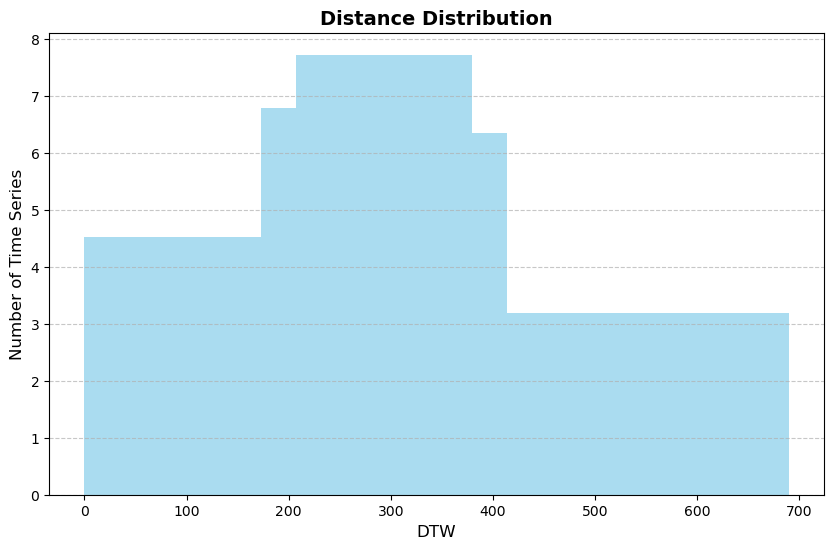

In [ ]:
hist, bins = ds_tree.histogram(ts_matrix[:, 0])

plt.figure(figsize=(10, 6))
    
# plt.stairs is perfect for pre-computed bin edges and values
plt.stairs(hist, bins, fill=True, color='skyblue', edgecolor='black', alpha=0.7)

plt.title("Distance Distribution", fontsize=14, fontweight='bold')
plt.xlabel("DTW", fontsize=12)
plt.ylabel("Number of Time Series", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
def print_dstree(node, level=0, prefix="Root: "):
    if node is None:
        return
    
    indent = "    " * level
    
    if node.is_leaf():
        print(f"{indent}{prefix}Leaf (Items: {node.count})")
    else:
        # Extract split info for internal nodes
        strat = node.splitting_strategy
        if strat and node.split_threshold:
            idx, strategy, measure = strat
            split_info = f"{strategy} on Seg {idx}({measure}) < {node.split_threshold:.2f}"
        else:
            split_info = "Un-split Internal Node"
            
        print(f"{indent}{prefix}Internal [{split_info}]")
        
        # Recursively print children
        print_dstree(node.left, level + 1, "L--> ")
        print_dstree(node.right, level + 1, "R--> ")

# Usage:
print_dstree(ds_tree.root)

Root: Internal [H_Split on Seg 0(mean) < -0.28]
    L--> Leaf (Items: 53)
    R--> Leaf (Items: 47)


In [ ]:
heuristic_node = ds_tree.heuristic_search(ts_matrix[:, 0])
heuristic_node.calc_min_dist(ts_matrix[:, 0])

([4.819731750640818,
  3.9708490414204496,
  0.058107928333388736,
  -7.671387803501567,
  1.0989490530525003,
  13.085307872949151,
  6.403191415187184,
  -7.946044687665918,
  -10.738101529796696,
  0.7742581087000231,
  7.772071936441543,
  0.1282118018384366,
  -2.489159709438374,
  -3.52005143974291,
  -9.5862120671827,
  -7.654849932919908,
  1.2702885053965005,
  6.721006643714242,
  -2.5958043335511203,
  -17.835303268332208,
  -12.741847287912504,
  -0.2529197517626152,
  1.0952155836493018,
  -7.131957961804366,
  -9.300802501031175,
  -9.062645728281407,
  -11.903315364251597,
  -11.071088181943896,
  -0.9433558657413909,
  -1.5189432107921317,
  -15.799663943046246,
  -23.64181228679166,
  -11.912237435336309,
  -3.4355503552569706,
  -5.8022949443037986,
  -13.97917827161386,
  -15.623729583941472,
  -16.211116674891727,
  -18.610810175847103,
  -10.314843182804744,
  -3.3169974987886546,
  -10.540435944235451,
  -25.558208186687573,
  -24.025587212312598,
  -8.96509798654